# Exploring kernel functions

In this tutorial we will see all kernel functions currently available in `smudgy`. 
We will deposit a particle dataset from a cosmological N-body simulation with different kernels and investigate the advantages of certain kernels wrt. dynamic range and power spectrum analysis.

First, let's load all necessary packages and modules.

In [60]:
import numpy as np
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import smudgy as sm
from smudgy import get_kernel_shapes_1D
from powerbox import get_power

In [61]:
try:
    plt.style.use('custom')
except:
    pass
%matplotlib inline
%config InlineBackend.figure_format='retina'

As discussed in the Kernels and Structures wiki page, `smudgy` supports `separable`, `isotropic` and `covariant` structures. Currently, only `tophat`, `tsc` and `gaussian` kernels can be used for `separable` structures, while all kernels can be used for the other two.

Let's define the structures and a dict with kernel names to analyze.

In [62]:
structures = ['separable', 'isotropic', 'covariant']

kernels_fixed = {
    'CIC': 'cic', 
    'TSC': 'tsc', 
    'PCS': 'pcs', 
    'PQS': 'pqs'
    }

kernels_adaptive = {
    "Tophat": "tophat",
    "TSC": "tsc",
    "Gaussian": "gaussian",

    "Lucy": "lucy",
    "Cubic Spline": "cubic_spline",
    "Quintic Spline": "quintic_spline",

    "Wendland C2": "wendland_c2",
    "Wendland C4": "wendland_c4",
    "Wendland C6": "wendland_c6",
    }

batch_1 = {name: kernels_adaptive[name] for name in list(kernels_adaptive.keys())[0:3]}
batch_2 = {name: kernels_adaptive[name] for name in list(kernels_adaptive.keys())[3:6]}
batch_3 = {name: kernels_adaptive[name] for name in list(kernels_adaptive.keys())[6:9]}
batches = [batch_1, batch_2, batch_3]

# Pre-store colors for fixed and adaptive kernels, drawn from two different colormaps
cmap_fixed = plt.get_cmap('viridis')
cmap_adaptive = plt.get_cmap('plasma')

colors_fixed = [
    cmap_fixed(i / max(len(kernels_fixed) - 1, 1))
    for i in range(len(kernels_fixed))
]
colors_adaptive = [
    cmap_adaptive(i / max(len(kernels_adaptive) - 1, 1))
    for i in range(len(kernels_adaptive))
]

## Kernel shape comparison

The following figure shows a comparison of all available 1D kernel functions in `smudgy`, where the normalized coordinate $q=|r|/h$.

In [63]:
fig, ax = plt.subplots(1, len(batches), sharex=True, sharey=True, figsize=(6, 2))

c = 0
for i, batch in enumerate(batches):
    for kernel_name, kernel_key in batch.items():
        q, values = get_kernel_shapes_1D(kernel_key)
        ax[i].plot(q, values, label=kernel_name, lw=0.8, color=colors_adaptive[c])
        c += 1
    ax[i].legend(fontsize=5, loc='upper right')
    ax[i].set_xlabel(r"Normalized coordinate $q$")

ax[0].set(
       ylabel="Kernel value",
       ylim=(0, None)
       )

fig.savefig("kernel_shapes.png", dpi=300, bbox_inches="tight")
plt.close()

[Taichi] Starting on arch=arm64
[Taichi] Starting on arch=arm64
[Taichi] Starting on arch=arm64


[W 08/05/26 16:06:27.794 1279653] [misc.py:adaptive_arch_select@758] Arch=['cpu'] is not supported, falling back to CPU
[W 08/05/26 16:06:27.918 1279653] [misc.py:adaptive_arch_select@758] Arch=['cpu'] is not supported, falling back to CPU
[W 08/05/26 16:06:28.037 1279653] [misc.py:adaptive_arch_select@758] Arch=['cpu'] is not supported, falling back to CPU


[Taichi] Starting on arch=arm64
[Taichi] Starting on arch=arm64


[W 08/05/26 16:06:28.160 1279653] [misc.py:adaptive_arch_select@758] Arch=['cpu'] is not supported, falling back to CPU
[W 08/05/26 16:06:28.276 1279653] [misc.py:adaptive_arch_select@758] Arch=['cpu'] is not supported, falling back to CPU
[W 08/05/26 16:06:28.397 1279653] [misc.py:adaptive_arch_select@758] Arch=['cpu'] is not supported, falling back to CPU


[Taichi] Starting on arch=arm64
[Taichi] Starting on arch=arm64


[W 08/05/26 16:06:28.518 1279653] [misc.py:adaptive_arch_select@758] Arch=['cpu'] is not supported, falling back to CPU
[W 08/05/26 16:06:28.638 1279653] [misc.py:adaptive_arch_select@758] Arch=['cpu'] is not supported, falling back to CPU


[Taichi] Starting on arch=arm64
[Taichi] Starting on arch=arm64


[W 08/05/26 16:06:28.781 1279653] [misc.py:adaptive_arch_select@758] Arch=['cpu'] is not supported, falling back to CPU


```{image} kernel_shapes.png
:width: 100%
:align: center

## Effect of kernel shape on Power Spectrum

Different kernels are defined over different support domains. Some kernels exhibit sharper and more concentrated shapes, while others are more smoothly extended. Therefore, interpolation and deposition results almost always depend on the chosen kernel. We demonstrate this in the following workflow, where we deposit particles from a cosmological N-body simulation using different kernel functions.

First, we compute a reference grid using Nearest Grid Point assignment (NGP), which is often used in such applications. Then, with NGP as the baseline we compare the results by using higher order kernels and finally show the relative difference on the power spectrum.

We use the TNG50-4-Dark simulation from the publically available [TNG](https://www.tng-project.org/data/) runs as well as the `illustris_python` package to load `positions`, `masses` and the `boxsize` information.

In [73]:
import illustris_python as il

basePath = '/Users/mauro/work/projects/smudgy/data/tng50_4_dark/'
snapNum = 99
boxsize = 35
dm = il.snapshot.loadSubset(basePath, snapNum, "dm")

positions = dm['Coordinates'] / 1000
masses = np.ones(len(positions)) * 1e4 #* 0.0186754872146347 * 1e10 # in Msun/h
positions = np.clip(positions, 0.01, boxsize-0.01)

Then we initialize a `PointCloud` object, set some parameters to use during later computations and compute the smoothing lengths. For this tutorial we use the `isotropic` kernel structure.

In [ ]:
pc = sm.PointCloud(
    positions=positions,
    weights=masses,
    boxsize=boxsize
    )
num_neighbors = 16

kwargs = dict(
    fields=pc.weights,
    averaged=False,
    #eta_crit=10.0
)

pc.global_setup(num_neighbors=num_neighbors, structure='isotropic')
pc.compute_smoothing()

[smudgy] Set taichi backend
[smudgy] Using 1 MPI rank
[smudgy] Initialized 3d PointCloud with 19683000 particles in periodic box of size=[35 35 35]
[smudgy] Set structure to 'isotropic'
[smudgy] Set number of neighbors to 16
[smudgy] Building kd-tree from positions
[smudgy] Computing smoothing lengths from 16 neighbors


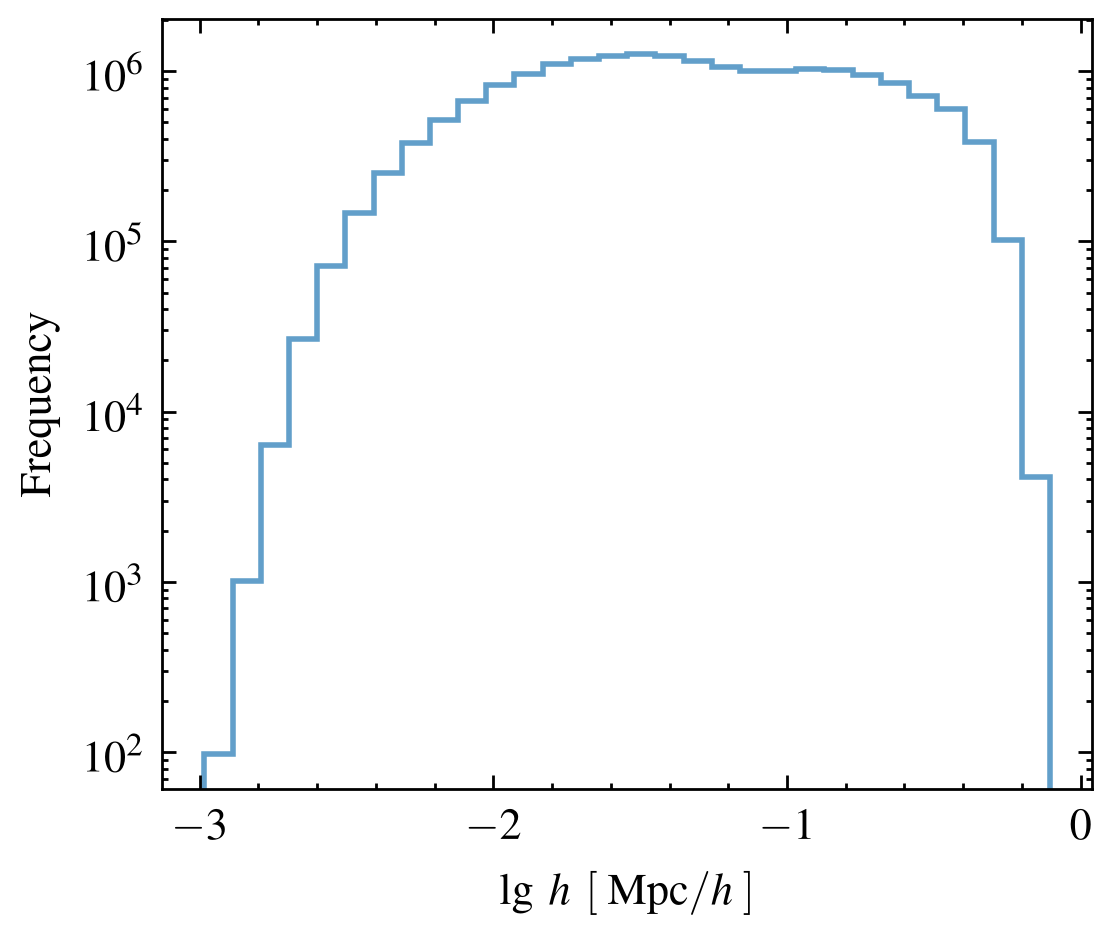

In [75]:
fig, ax = plt.subplots(figsize=(3, 2.5))
ax.hist(np.log10(pc.smoothing.smoothing_lengths), bins=30, color='C0', alpha=0.7, histtype='step', log=True)
ax.set_xlabel(r"$\lg \; h \; \left[\; \mathrm{Mpc} / h \; \right]$")
ax.set_ylabel("Frequency")
plt.show()

In [76]:
kwargs['gridnums'] = 128 # int(boxsize / np.median(pc.smoothing.smoothing_lengths) // 2)
print(f"Gridnums: {kwargs['gridnums']}")

Gridnums: 128


Next we deposit the particles using all the available kernels in `smudgy` and store the following grids: 
+ A reference grid using the widely adopted NGP method (essentially a 3D-histogramm of the point pc). 
+ Grids using fixed kernel methods.
+ Grids using the adaptive kernel method.

In [77]:
f_ref = pc.deposit(
    **kwargs,
    kernel_name='ngp',
    adaptive=False
)[0]

maps_fixed = []
for kernel_name, kernel_key in kernels_fixed.items():

    f = pc.deposit(
        **kwargs,
        kernel_name=kernel_key,
        adaptive=False
    )[0]
    maps_fixed.append(f)

maps_adaptive = []
for kernel_name, kernel_key in kernels_adaptive.items():

    f = pc.deposit(
        **kwargs,
        kernel_name=kernel_key,
        adaptive=True
    )[0]
    maps_adaptive.append(f)

[smudgy] Depositing using  'ngp' kernel
[smudgy] Depositing using  'cic' kernel
[smudgy] Depositing using  'tsc' kernel
[smudgy] Depositing using  'pcs' kernel
[smudgy] Depositing using  'pqs' kernel
[smudgy] Depositing using isotropic 'tophat' kernel
[smudgy] Depositing using isotropic 'tsc' kernel
[smudgy] Depositing using isotropic 'gaussian' kernel
[smudgy] Depositing using isotropic 'lucy' kernel
[smudgy] Depositing using isotropic 'cubic_spline' kernel
[smudgy] Depositing using isotropic 'quintic_spline' kernel
[smudgy] Depositing using isotropic 'wendland_c2' kernel
[smudgy] Depositing using isotropic 'wendland_c4' kernel
[smudgy] Depositing using isotropic 'wendland_c6' kernel


The figure below show a visual comparison between the reference volume and the adaptive methods.

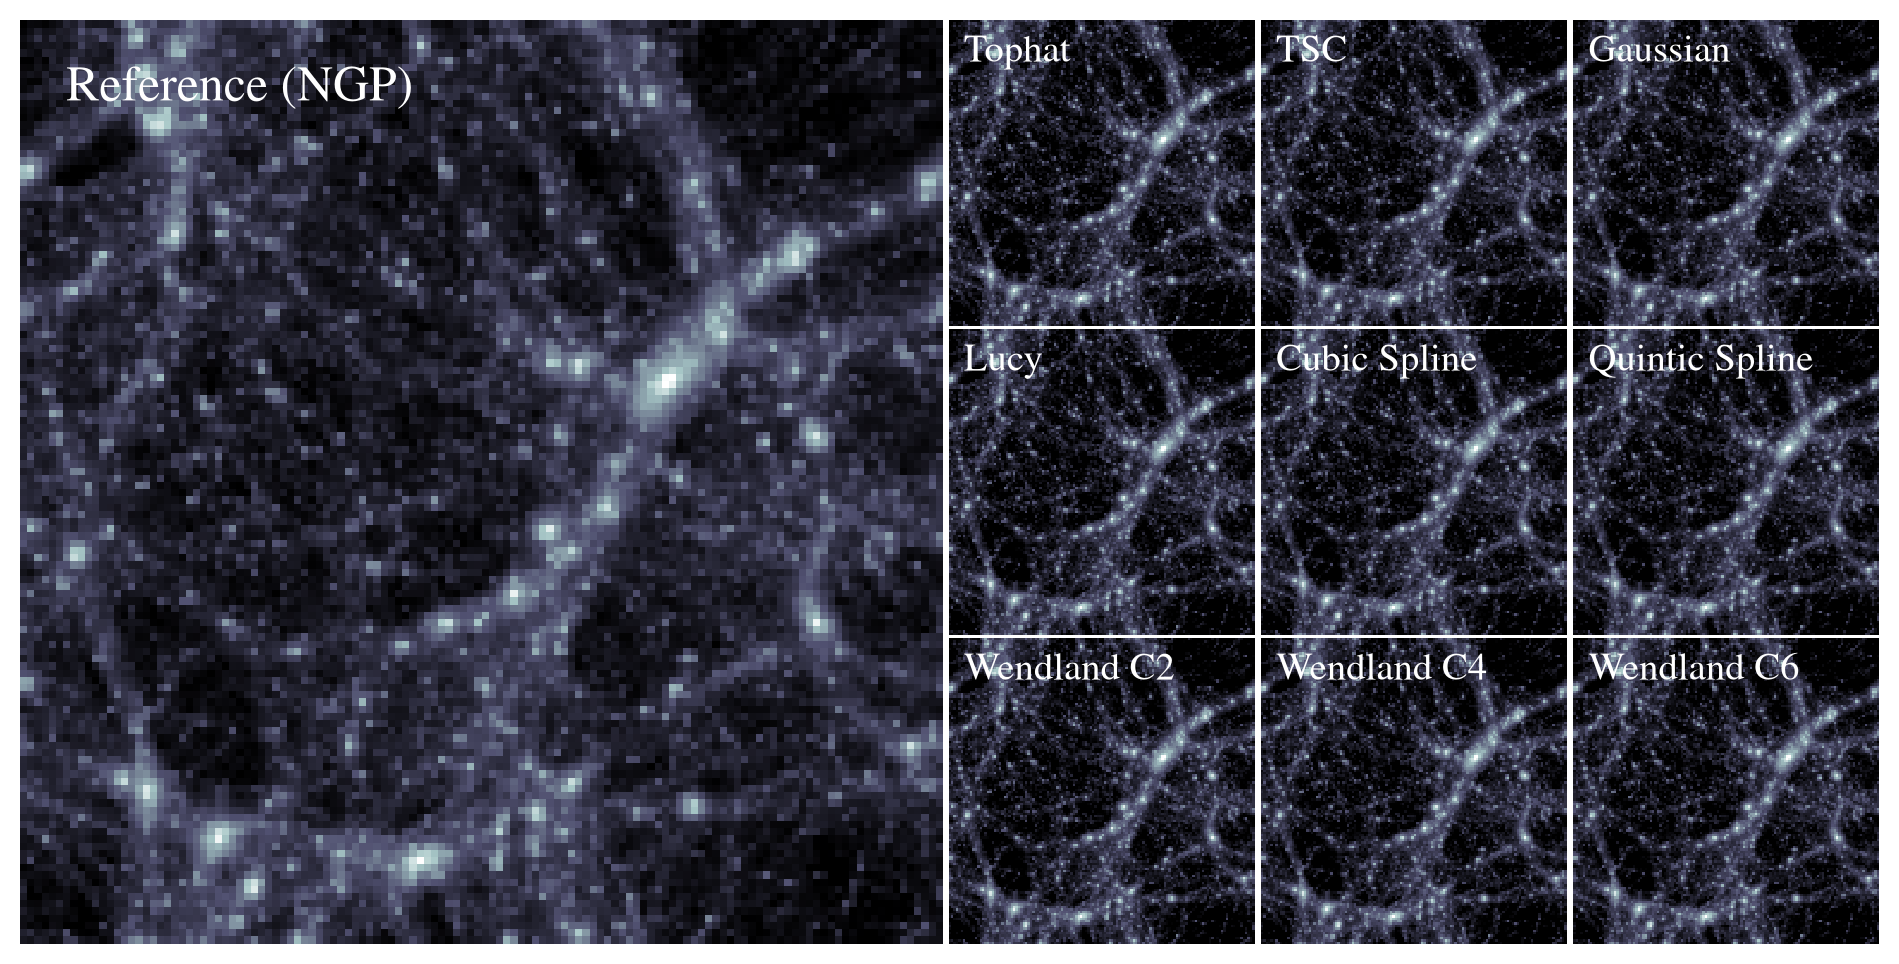

In [78]:
ref_proj = f_ref.sum(axis=0)
ref_log = np.log10(ref_proj + 1)
vmin, vmax = np.percentile(ref_log, 1), np.percentile(ref_log, 99.99)


fig = plt.figure(figsize=(6, 3))
gs = gridspec.GridSpec(3, 4, width_ratios=[3, 1, 1, 1], wspace=0.01, hspace=0.01)

# Left Panel: Reference (NGP)
ax_ref = fig.add_subplot(gs[:, 0])
ax_ref.imshow(ref_log.T, origin='lower', cmap='bone', interpolation='none', vmin=vmin, vmax=vmax)
ax_ref.axis('off')
ax_ref.text(0.05, 0.95, "Reference (NGP)", color='white',
            transform=ax_ref.transAxes, va='top', fontsize=9, fontweight='bold')

for i, (name, _) in enumerate(kernels_adaptive.items()):
    row, col = divmod(i, 3)
    ax = fig.add_subplot(gs[row, col+1])

    # Calculate relative difference of the log10 fields
    kernel_proj = maps_adaptive[i].sum(axis=0)
    kernel_log = np.log10(kernel_proj + 1)

    ax.imshow(kernel_log.T, origin='lower', vmin=vmin, vmax=vmax, cmap='bone', interpolation='none')
    ax.text(0.05, 0.95, name, color='white', transform=ax.transAxes, va='top', fontsize=7)
    ax.axis('off')

fig.savefig("kernel_projection_comparison.png", dpi=300, bbox_inches="tight")
#plt.close()

```{image} kernel_projection_comparison.png
:width: 100%
:align: center

Next, we use the `get_power` function from the [`powerbox`](https://powerbox.readthedocs.io/en/latest/#) package to compute power spectra for the baseline and kernel maps.

In [79]:
pk_ref, k_ref = get_power(f_ref, boxlength=boxsize)

power_spectra_fixed = []    
power_spectra_adaptive = []

print(masses.sum(), "Total mass in Msun/h")
print(f_ref.sum(), "Reference sum")

eps = 1
for f in maps_fixed:
    print(f.sum(), "Fixed kernel sum")
    p, k = get_power(f + eps, boxlength=boxsize)
    power_spectra_fixed.append(p)

for f in maps_adaptive:
    print(f.sum(), "Adaptive kernel sum")
    p, k = get_power(f + eps, boxlength=boxsize)
    power_spectra_adaptive.append(p)


/opt/anaconda3/envs/smudgy_dev_env/lib/python3.13/site-packages/powerbox/tools.py:261: FutureWarning: In the future, bins will be generated by default up to the smallest length over any dimension, instead of the largest magnitude for the box.Set bins_upto_boxlen to silence this warning.
  bins = _getbins(bins, coord_mags, log_bins, bins_upto_boxlen=bins_upto_boxlen)


196830000000.0 Total mass in Msun/h
1.9683028e+15 Reference sum
1.9682987e+15 Fixed kernel sum
1.9682802e+15 Fixed kernel sum
1.9682539e+15 Fixed kernel sum
1.9682116e+15 Fixed kernel sum
1.8042531e+15 Adaptive kernel sum
1.804952e+15 Adaptive kernel sum
1.8039005e+15 Adaptive kernel sum
1.805004e+15 Adaptive kernel sum
1.8042626e+15 Adaptive kernel sum
1.8038638e+15 Adaptive kernel sum
1.8044545e+15 Adaptive kernel sum
1.8046178e+15 Adaptive kernel sum
1.804365e+15 Adaptive kernel sum


Finally we compare the power spectra wrt. the baseline (NGP). For the chosen deposition parameters, we see that different kernels can have a relatively large impact (order percentage) especially on scales $x \leq 1 \, \mathrm{cMpc}/h$

/var/folders/g9/6lkt0k991jsbvwhk4pft359m0000gn/T/ipykernel_66604/3567819827.py:12: RuntimeWarning: divide by zero encountered in divide
  return 2 * np.pi / x


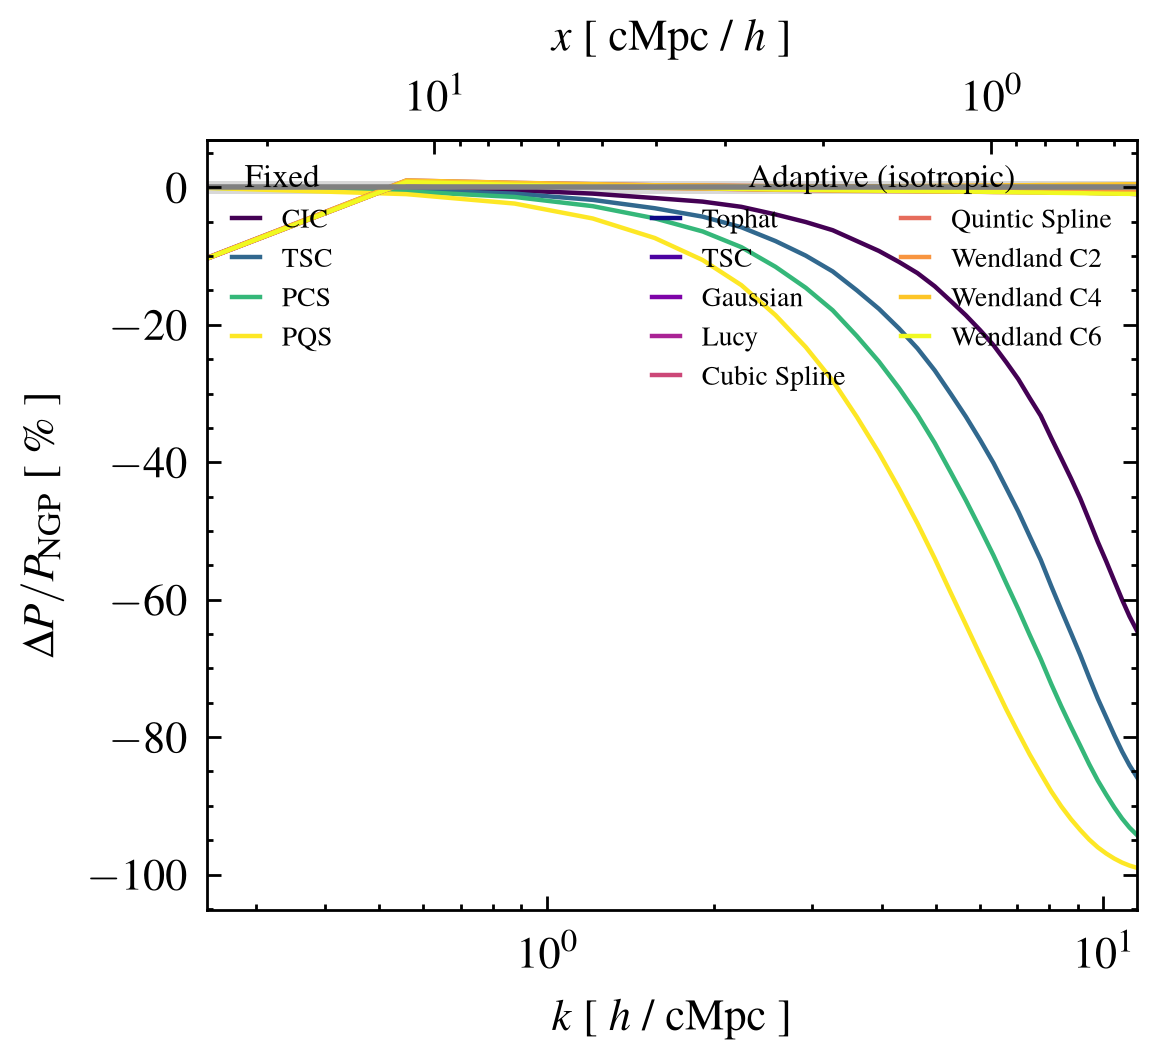

In [80]:
def relative_difference(a, b):
    # Avoid division by zero
    mask = (b != 0)
    res = np.zeros_like(a)
    res[mask] = (a[mask] - b[mask]) / b[mask] * 100
    return res

def k2x(k):
    return 2 * np.pi / k

def x2k(x):
    return 2 * np.pi / x

# set k_nyq to upper xlim
k_nyq = np.pi * kwargs['gridnums'] / boxsize

fig, ax = plt.subplots(figsize=(3, 2.5))

#ax.loglog(k_ref, pk_ref, label="Reference (NGP)", lw=1.0, color='black', ls='--')

for i, (name, _) in enumerate(kernels_fixed.items()):
    rel_diff = relative_difference(power_spectra_fixed[i], pk_ref)
    ax.semilogx(k, rel_diff, label=name, lw=0.8, color=colors_fixed[i])
    #ax.loglog(k, power_spectra_fixed[i], label=name, lw=0.8, color=colors_fixed[i])

for i, (name, _) in enumerate(kernels_adaptive.items()):
    rel_diff = relative_difference(power_spectra_adaptive[i], pk_ref)
    ax.semilogx(k, rel_diff, label=name, lw=0.8, color=colors_adaptive[i])
    #ax.loglog(k, power_spectra_adaptive[i], label=name, lw=0.8, color=colors_adaptive[i])

ax_top = ax.secondary_xaxis('top', functions=(k2x, x2k))
ax_top.set_xlabel(r"$x$ [ cMpc / $h$ ]")
ax_top.tick_params(which='both', top=True, labeltop=True)
ax.tick_params(which='both', top=False, labeltop=False)

ax.fill_between([k_ref.min(), k_ref.max()], -1, 1, color='gray', alpha=0.3, edgecolor='none')
ax.axhline(0, linestyle='-', lw=1, color='gray')
ax.set(xlim=(k_ref.min(), k_nyq),
       #ylim=(-8, 6),
       xlabel=r"$k$ [ $h$ / cMpc ]",
       ylabel=r"$\Delta P / P_{\rm NGP}$ [ \% ]",
       )

# Fixed
handles_fixed, labels_fixed = ax.get_legend_handles_labels()

leg1 = ax.legend(
    handles_fixed[:len(kernels_fixed)],
    labels_fixed[:len(kernels_fixed)],
    title="Fixed",
    fontsize=5,
    title_fontsize=6,
    loc="upper left",
    handlelength=1.0,
    frameon=False,
)
ax.add_artist(leg1)

# Adaptive
leg2 = ax.legend(
    handles_fixed[len(kernels_fixed):],
    labels_fixed[len(kernels_fixed):],
    title="Adaptive (isotropic)",
    fontsize=5,
    title_fontsize=6,
    ncols=2,
    loc="upper right",
    handlelength=1.0,
    frameon=False,
)

fig.savefig("kernel_power_comparison.png", dpi=300, bbox_inches="tight")
#plt.close()

```{image} kernel_power_comparison.png
:width: 70%
:align: center